In [1]:
#pip install torch torchvision torchaudio opencv-python scikit-learn matplotlib seaborn numpy Pillow

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Cell 1 — Import all required libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

print('PyTorch version:', torch.__version__)
print('CUDA available :', torch.cuda.is_available())
print('All libraries imported successfully.')

# Use GPU if available, otherwise fall back to CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device   :', DEVICE)

PyTorch version: 2.11.0+cpu
CUDA available : False
All libraries imported successfully.
Using device   : cpu


In [2]:
# Cell 2 — Dataset path and parameters
import os

# Force the working directory to the correct location
os.chdir(r'C:\Users\DELL\Ai&Machine learnig\Machine  Learning')

DATASET_PATH = 'faces'
IMG_SIZE     = (128, 128)
VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.JPG', '.JPEG', '.PNG', '.BMP')

print("Current directory:", os.getcwd())
print("faces exists:", os.path.exists(DATASET_PATH))
print("Contents:", os.listdir(DATASET_PATH))

Current directory: C:\Users\DELL\Ai&Machine learnig\Machine  Learning
faces exists: True
Contents: ['STU001', 'STU002', 'STU004', 'STU006', 'STU007', 'STU010', 'STU011', 'STU012', 'STU013', 'STU016', 'STU017', 'STU018', 'STU019', 'STU020', 'STU021', 'STU022', 'STU023', 'STU024', 'STU026', 'STU027', 'STU028', 'STU031', 'STU032', 'STU033', 'STU034', 'STU035', 'STU038', 'STU039', 'STU040', 'STU041', 'STU042', 'STU043', 'STU047', 'STU058', 'STU060', 'STU065', 'STU070', 'STU071']


In [3]:
# Cell 3 — Load all images and labels
raw_images = []   # numpy arrays of pixel data
labels     = []   # student ID strings
bad_files  = []   # files that cannot be loaded

student_folders = sorted(os.listdir(DATASET_PATH))

for student_id in student_folders:
    folder_path = os.path.join(DATASET_PATH, student_id)
    if not os.path.isdir(folder_path):
        continue  # skip any loose files at the top level

    for filename in sorted(os.listdir(folder_path)):
        if not filename.lower().endswith(VALID_EXTENSIONS):
            continue  # skip non-image files

        file_path = os.path.join(folder_path, filename)
        img = cv2.imread(file_path)

        if img is None:
            bad_files.append(file_path)
            print(f'WARNING: Could not load {file_path}')
            continue

        raw_images.append(img)
        labels.append(student_id)

print(f'Total images loaded      : {len(raw_images)}')
print(f'Total students found     : {len(set(labels))}')
print(f'Corrupted/unreadable files: {len(bad_files)}')

Total images loaded      : 143
Total students found     : 35
Corrupted/unreadable files: 0


Images per student:
  STU001: 4 images
  STU004: 4 images
  STU006: 4 images
  STU007: 4 images
  STU010: 4 images
  STU011: 4 images
  STU012: 4 images
  STU013: 4 images
  STU016: 4 images
  STU017: 4 images
  STU018: 4 images
  STU019: 4 images
  STU020: 4 images
  STU021: 4 images
  STU022: 4 images
  STU023: 4 images
  STU026: 8 images
  STU027: 4 images
  STU028: 4 images
  STU031: 4 images
  STU032: 4 images
  STU033: 4 images
  STU034: 4 images
  STU035: 4 images
  STU038: 4 images
  STU039: 4 images
  STU041: 4 images
  STU042: 4 images
  STU043: 4 images
  STU047: 4 images
  STU058: 4 images
  STU060: 4 images
  STU065: 4 images
  STU070: 3 images
  STU071: 4 images


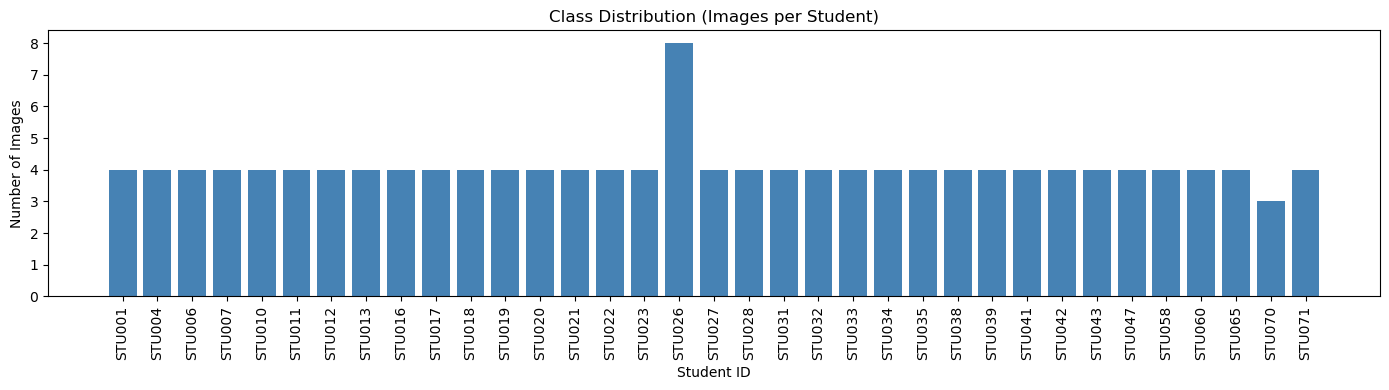

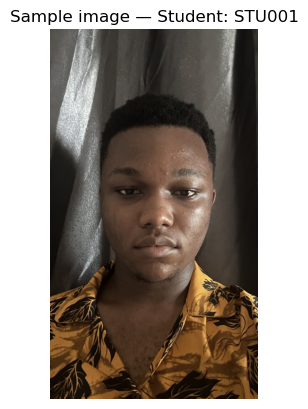

Unique image shapes found: {(1280, 960, 3), (1280, 975, 3), (1280, 1160, 3), (2513, 2380, 3), (1080, 707, 3), (1052, 780, 3), (2560, 1920, 3), (303, 284, 3), (405, 404, 3), (1280, 719, 3), (1080, 810, 3), (2560, 1440, 3), (960, 540, 3), (1280, 1047, 3), (4080, 3060, 3), (1280, 1280, 3), (2562, 2573, 3), (1080, 812, 3), (1280, 983, 3), (1280, 1238, 3), (1600, 1200, 3), (1280, 954, 3), (2248, 2202, 3), (343, 339, 3), (1280, 1090, 3), (1261, 928, 3), (1280, 1070, 3), (359, 376, 3), (3088, 1737, 3), (2314, 2314, 3)}


In [4]:
# Cell 4 — Explore: class distribution + sample image
label_counts = Counter(labels)

print('Images per student:')
for student, count in sorted(label_counts.items()):
    print(f'  {student}: {count} images')

# Bar chart
plt.figure(figsize=(14, 4))
plt.bar(label_counts.keys(), label_counts.values(), color='steelblue')
plt.xlabel('Student ID')
plt.ylabel('Number of Images')
plt.title('Class Distribution (Images per Student)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Sample image from the first student
sample_img = cv2.cvtColor(raw_images[0], cv2.COLOR_BGR2RGB)
plt.imshow(sample_img)
plt.title(f'Sample image — Student: {labels[0]}')
plt.axis('off')
plt.show()

# Check original image sizes
shapes = [img.shape for img in raw_images]
unique_shapes = set(shapes)
print('Unique image shapes found:', unique_shapes)

In [5]:
# Cell 5 — Remove images that are too small (< 30 × 30 pixels)
MIN_DIM = 30

cleaned_images = []
cleaned_labels = []
removed_count  = 0

for img, label in zip(raw_images, labels):
    h, w = img.shape[:2]
    if h < MIN_DIM or w < MIN_DIM:
        removed_count += 1
        print(f'Removed tiny image ({w}×{h}) for student {label}')
        continue
    cleaned_images.append(img)
    cleaned_labels.append(label)

print(f'Images removed (too small) : {removed_count}')
print(f'Images remaining           : {len(cleaned_images)}')

Images removed (too small) : 0
Images remaining           : 143


In [6]:
# Cell 6 — Remove near-duplicate images using average hashing
def average_hash(img, hash_size=8):
    """Compute a simple average hash for an image."""
    gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (hash_size, hash_size))
    mean_val = resized.mean()
    return tuple((resized > mean_val).flatten().astype(int))

seen_hashes  = set()
deduped_images = []
deduped_labels = []
dup_count = 0

for img, label in zip(cleaned_images, cleaned_labels):
    h = average_hash(img)
    if h in seen_hashes:
        dup_count += 1
        continue
    seen_hashes.add(h)
    deduped_images.append(img)
    deduped_labels.append(label)

print(f'Duplicate images removed    : {dup_count}')
print(f'Images after deduplication  : {len(deduped_images)}')

# Safety check — warn if any student lost images
post_dedup_counts = Counter(deduped_labels)
for student, count in sorted(post_dedup_counts.items()):
    orig = label_counts[student]
    if count < orig:
        print(f'  NOTE: {student} went from {orig} → {count} images after dedup')

Duplicate images removed    : 2
Images after deduplication  : 141
  NOTE: STU065 went from 4 → 3 images after dedup
  NOTE: STU070 went from 3 → 2 images after dedup


In [7]:
# Cell 7 — Resize all images to IMG_SIZE (INTER_AREA is best for shrinking)
resized_images = []
for img in deduped_images:
    resized = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    resized_images.append(resized)

print(f'All images resized to {IMG_SIZE[0]}×{IMG_SIZE[1]} pixels.')
print(f'Sample shape: {resized_images[0].shape}')

All images resized to 128×128 pixels.
Sample shape: (128, 128, 3)


In [8]:
# Cell 8 — Convert BGR (OpenCV default) to RGB (PyTorch / matplotlib standard)
rgb_images = []
for img in resized_images:
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    rgb_images.append(rgb)

print('Color channels converted from BGR to RGB.')

Color channels converted from BGR to RGB.


In [9]:
# Cell 9 — Stack into NumPy arrays
X     = np.array(rgb_images,      dtype=np.float32)  # (N, 128, 128, 3)
y_raw = np.array(deduped_labels)                      # (N,)

print('Image array shape :', X.shape)
print('Labels array shape:', y_raw.shape)

Image array shape : (141, 128, 128, 3)
Labels array shape: (141,)


In [10]:
# Cell 10 — Encode string labels as integers (required by PyTorch CrossEntropyLoss)
le        = LabelEncoder()
y_encoded = le.fit_transform(y_raw)   # e.g. STU001 → 0, STU002 → 1
NUM_CLASSES = len(le.classes_)

print(f'Number of unique students (classes): {NUM_CLASSES}')
print('Class mapping (first 5):',
      dict(zip(le.classes_[:5], range(5))))
print('Labels are integer-encoded — no one-hot encoding needed for PyTorch.')

Number of unique students (classes): 35
Class mapping (first 5): {np.str_('STU001'): 0, np.str_('STU004'): 1, np.str_('STU006'): 2, np.str_('STU007'): 3, np.str_('STU010'): 4}
Labels are integer-encoded — no one-hot encoding needed for PyTorch.


In [11]:
# Cell 11 — Normalise pixel values from [0, 255] to [0.0, 1.0]
X_scaled = X / 255.0

print('Pixel value range before scaling: 0 to 255')
print(f'Pixel value range after scaling : {X_scaled.min():.4f} to {X_scaled.max():.4f}')

Pixel value range before scaling: 0 to 255
Pixel value range after scaling : 0.0000 to 1.0000


In [12]:
# Cell 12 — Train / Test split
TEST_SIZE   = 0.3   # increased to 30% so test set has enough samples per class
RANDOM_SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size    = TEST_SIZE,
    random_state = RANDOM_SEED,
    stratify     = y_encoded
)

print(f'Training set size: {X_train.shape[0]} images')
print(f'Test set size    : {X_test.shape[0]} images')

Training set size: 98 images
Test set size    : 43 images


In [13]:
# Cell 13 — Custom PyTorch Dataset class
class FaceDataset(Dataset):
    """
    Custom PyTorch Dataset for student face images.

    Parameters
    ----------
    images    : numpy array (N, H, W, 3), float32, range [0, 1]
    labels    : numpy array of integer class indices
    transform : torchvision transform pipeline
                  training → augmentations + ToTensor
                  testing  → ToTensor only
    """
    def __init__(self, images, labels, transform=None):
        self.images    = images
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # float32 [0,1] → uint8 [0,255] → PIL Image (required by torchvision)
        img_uint8 = (self.images[idx] * 255).astype(np.uint8)
        img_pil   = Image.fromarray(img_uint8)

        if self.transform:
            img_tensor = self.transform(img_pil)
        else:
            img_tensor = transforms.ToTensor()(img_pil)

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img_tensor, label

print('FaceDataset class defined.')

FaceDataset class defined.


In [14]:
# Cell 14 — Define augmentation transforms
# Training: random augmentations to artificially enlarge the small dataset
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=15),                        # Rotate ± 15°
    transforms.RandomHorizontalFlip(p=0.5),                       # Mirror left-right
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),     # Shift ± 10 %
    transforms.ColorJitter(brightness=0.2, contrast=0.1),         # Vary brightness/contrast
    transforms.RandomResizedCrop(size=(128, 128), scale=(0.9, 1.0)),  # Slight zoom
    transforms.ToTensor(),                                        # PIL → (C, H, W) float
])

# Test: no augmentation — only convert to tensor
test_transform = transforms.Compose([
    transforms.ToTensor(),
])

print('Transforms defined.')
print('Training augmentations : rotation, flip, shift, brightness, zoom')
print('Test transform         : ToTensor only (no augmentation)')

Transforms defined.
Training augmentations : rotation, flip, shift, brightness, zoom
Test transform         : ToTensor only (no augmentation)


In [15]:
# Cell 15 — Create Datasets and DataLoaders
BATCH_SIZE = 16

train_dataset = FaceDataset(X_train, y_train, transform=train_transform)
test_dataset  = FaceDataset(X_test,  y_test,  transform=test_transform)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True,  num_workers=0)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=0)

print(f'Training samples  : {len(train_dataset)}')
print(f'Test samples      : {len(test_dataset)}')
print(f'Training batches  : {len(train_loader)}')
print(f'Test batches      : {len(test_loader)}')

Training samples  : 98
Test samples      : 43
Training batches  : 7
Test batches      : 3


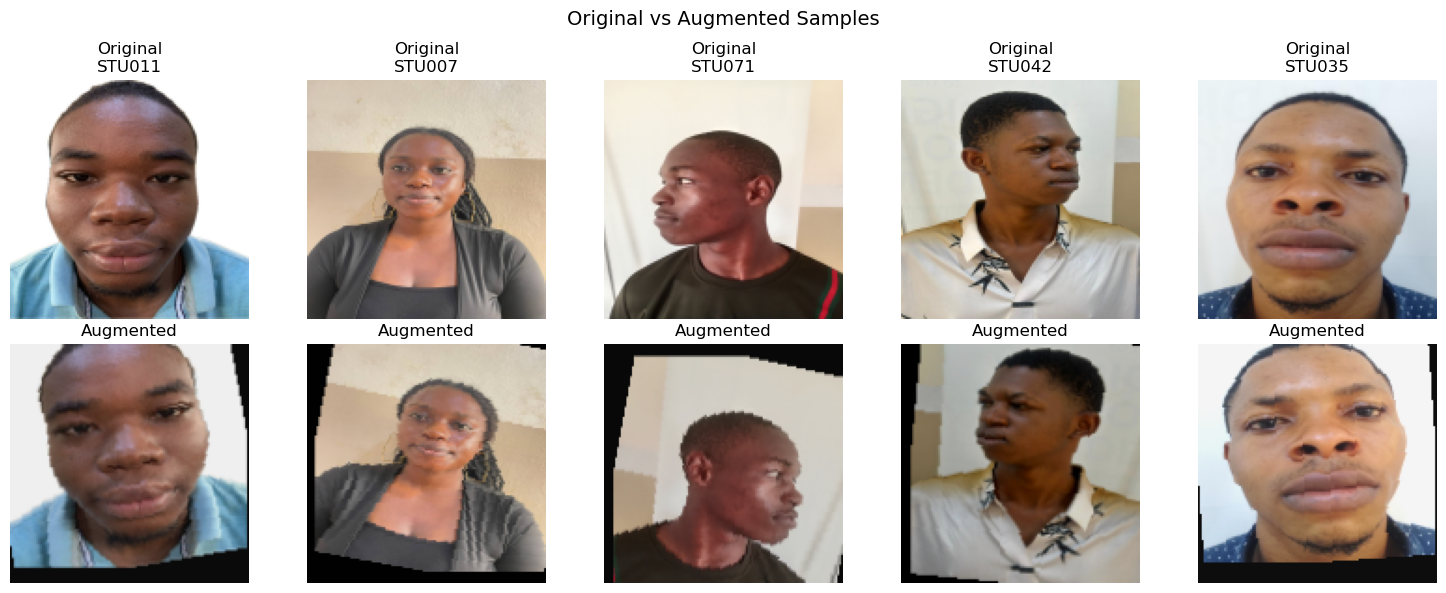

In [16]:
# Cell 16 — Visualise original vs augmented samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Original vs Augmented Samples', fontsize=14)

# Row 1 — originals
for i in range(5):
    axes[0, i].imshow(X_train[i])
    axes[0, i].set_title(f'Original\n{le.classes_[y_train[i]]}')
    axes[0, i].axis('off')

# Row 2 — augmented versions
for i in range(5):
    img_uint8  = (X_train[i] * 255).astype(np.uint8)
    img_pil    = Image.fromarray(img_uint8)
    aug_tensor = train_transform(img_pil)
    aug_np     = aug_tensor.permute(1, 2, 0).numpy()  # (C,H,W) → (H,W,C)
    aug_np     = np.clip(aug_np, 0, 1)
    axes[1, i].imshow(aug_np)
    axes[1, i].set_title('Augmented')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [17]:
# Cell 17 — Define the FaceCNN architecture
class FaceCNN(nn.Module):
    """
    CNN for student face recognition.

    Architecture
    ------------
    3 convolutional blocks  → Conv2d + BatchNorm + ReLU + MaxPool + Dropout2d
    Global Average Pooling  → reduces (N, 128, H, W) to (N, 128)
    Classifier              → Linear(128→256) + Dropout + Linear(256→128) + Linear(128→num_classes)
    """

    def __init__(self, num_classes):
        super(FaceCNN, self).__init__()

        # Block 1: low-level features (edges, colour blobs)
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=0.25)
        )

        # Block 2: mid-level features (textures, curves)
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=0.25)
        )

        # Block 3: high-level features (face parts)
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=0.40)
        )

        # Global Average Pooling: (N, 128, H, W) → (N, 128, 1, 1)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Fully connected classifier
        self.classifier = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes)
            # No Softmax — CrossEntropyLoss applies it internally
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)   # Flatten: (N, 128, 1, 1) → (N, 128)
        x = self.classifier(x)
        return x


model = FaceCNN(num_classes=NUM_CLASSES).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')

FaceCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False

In [18]:
# Cell 18 — lower learning rate for better convergence
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr           = 0.0005,
    weight_decay = 1e-4
)

# Learning rate scheduler (verbose removed for compatibility)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

print('Loss function : CrossEntropyLoss')
print('Optimiser     : Adam  (lr=0.0005, weight_decay=1e-4)')
print('Scheduler     : ReduceLROnPlateau')
print('Model on      :', DEVICE)

Loss function : CrossEntropyLoss
Optimiser     : Adam  (lr=0.0005, weight_decay=1e-4)
Scheduler     : ReduceLROnPlateau
Model on      : cpu


In [19]:
# Cell 19 — Training and evaluation helper functions
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run one full pass over the training data and update weights."""
    model.train()  # enable dropout + batchnorm training behaviour
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()             # clear gradients from previous step
        outputs = model(images)           # forward pass
        loss    = criterion(outputs, labels)  # compute loss
        loss.backward()                   # backpropagation
        optimizer.step()                  # update weights

        total_loss += loss.item() * images.size(0)
        _, preds    = torch.max(outputs, 1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model on a DataLoader without updating weights."""
    model.eval()  # disable dropout, use running stats in BatchNorm
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():  # no gradient computation needed
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, preds    = torch.max(outputs, 1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / total, correct / total


print('Training helper functions defined.')

Training helper functions defined.


In [20]:
# Cell 20 — increase epochs and patience
EPOCHS    = 150      # was 80
PATIENCE  = 20       # was 10
SAVE_PATH = 'best_face_model.pth'

best_val_loss  = float('inf')
epochs_no_imp  = 0
best_weights   = None
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss,   val_acc   = evaluate(model, test_loader, criterion, DEVICE)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:3d}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}')

    # Checkpoint the best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_imp = 0
        best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
        torch.save(model.state_dict(), SAVE_PATH)
        print(f'  --> Best model saved (val_loss={best_val_loss:.4f})')
    else:
        epochs_no_imp += 1
        if epochs_no_imp >= PATIENCE:
            print(f'\nEarly stopping triggered at epoch {epoch}.')
            break

# Restore the best weights
model.load_state_dict(best_weights)
print('\nTraining complete. Best weights restored.')

Epoch   1/150 | Train Loss: 3.5752  Acc: 0.0102 | Val Loss: 3.5539  Acc: 0.0698
  --> Best model saved (val_loss=3.5539)
Epoch   2/150 | Train Loss: 3.5902  Acc: 0.0204 | Val Loss: 3.5530  Acc: 0.0698
  --> Best model saved (val_loss=3.5530)
Epoch   3/150 | Train Loss: 3.5423  Acc: 0.0408 | Val Loss: 3.5524  Acc: 0.0698
  --> Best model saved (val_loss=3.5524)
Epoch   4/150 | Train Loss: 3.5284  Acc: 0.0918 | Val Loss: 3.5518  Acc: 0.0698
  --> Best model saved (val_loss=3.5518)
Epoch   5/150 | Train Loss: 3.5640  Acc: 0.0408 | Val Loss: 3.5499  Acc: 0.0698
  --> Best model saved (val_loss=3.5499)
Epoch   6/150 | Train Loss: 3.5502  Acc: 0.0204 | Val Loss: 3.5473  Acc: 0.0698
  --> Best model saved (val_loss=3.5473)
Epoch   7/150 | Train Loss: 3.5435  Acc: 0.0306 | Val Loss: 3.5436  Acc: 0.0698
  --> Best model saved (val_loss=3.5436)
Epoch   8/150 | Train Loss: 3.5266  Acc: 0.0408 | Val Loss: 3.5404  Acc: 0.0698
  --> Best model saved (val_loss=3.5404)
Epoch   9/150 | Train Loss: 3.53

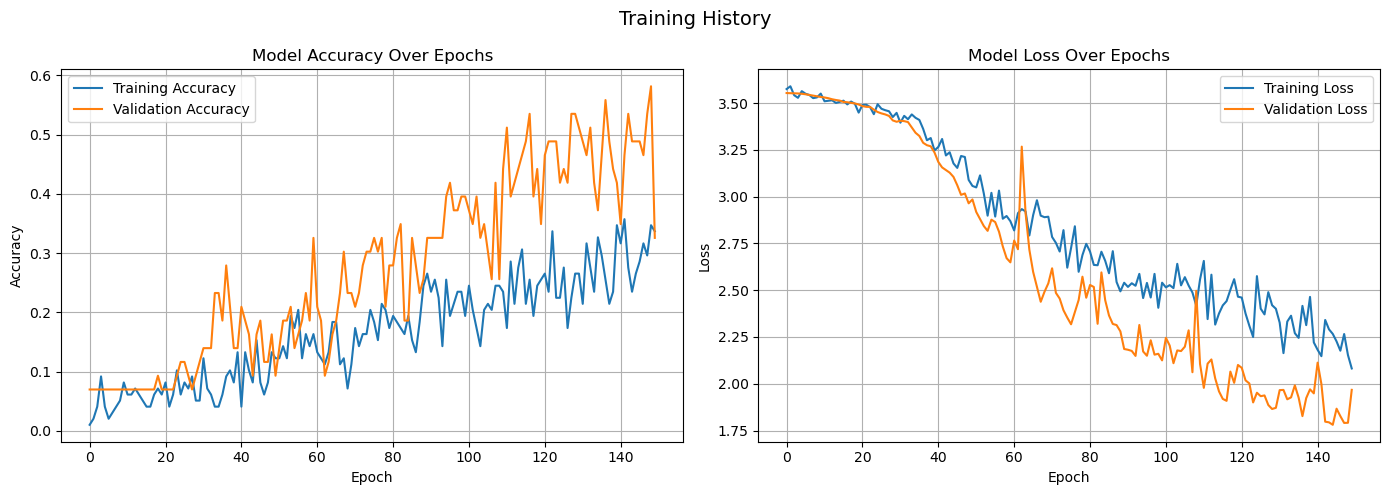

In [21]:
# Cell 21 — Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history['train_acc'], label='Training Accuracy')
ax1.plot(history['val_acc'],   label='Validation Accuracy')
ax1.set_title('Model Accuracy Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history['train_loss'], label='Training Loss')
ax2.plot(history['val_loss'],   label='Validation Loss')
ax2.set_title('Model Loss Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('Training History', fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
# Cell 22 — Generate predictions on the test set
model.eval()
all_preds = []
all_true  = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(DEVICE)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.numpy())

y_pred_encoded = np.array(all_preds)
y_test_encoded = np.array(all_true)

print(f'Predictions generated for {len(y_pred_encoded)} test images.')

Predictions generated for 43 test images.


In [23]:
# Cell 23 — Overall evaluation metrics
acc  = accuracy_score(y_test_encoded, y_pred_encoded)
prec = precision_score(y_test_encoded, y_pred_encoded, average='weighted', zero_division=0)
rec  = recall_score(y_test_encoded,    y_pred_encoded, average='weighted', zero_division=0)
f1   = f1_score(y_test_encoded,        y_pred_encoded, average='weighted', zero_division=0)

print('=' * 45)
print('MODEL EVALUATION RESULTS')
print('=' * 45)
print(f'Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-Score  : {f1:.4f}')
print('=' * 45)

MODEL EVALUATION RESULTS
Accuracy  : 0.4884  (48.84%)
Precision : 0.3729
Recall    : 0.4884
F1-Score  : 0.3989


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique class

In [24]:
# Cell 24 — Per-class classification report
report = classification_report(
    y_test_encoded,
    y_pred_encoded,
    target_names = le.classes_,
    zero_division = 0
)
print('CLASSIFICATION REPORT')
print(report)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      STU001       1.00      1.00      1.00         1
      STU004       1.00      1.00      1.00         1
      STU006       0.00      0.00      0.00         1
      STU007       1.00      1.00      1.00         1
      STU010       0.00      0.00      0.00         1
      STU011       0.50      1.00      0.67         1
      STU012       0.00      0.00      0.00         2
      STU013       1.00      1.00      1.00         2
      STU016       1.00      1.00      1.00         1
      STU017       1.00      1.00      1.00         1
      STU018       0.00      0.00      0.00         2
      STU019       1.00      1.00      1.00         1
      STU020       0.00      0.00      0.00         1
      STU021       1.00      1.00      1.00         1
      STU022       0.00      0.00      0.00         2
      STU023       0.33      1.00      0.50         1
      STU026       0.50      0.33      0.40         3
     

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is g

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)


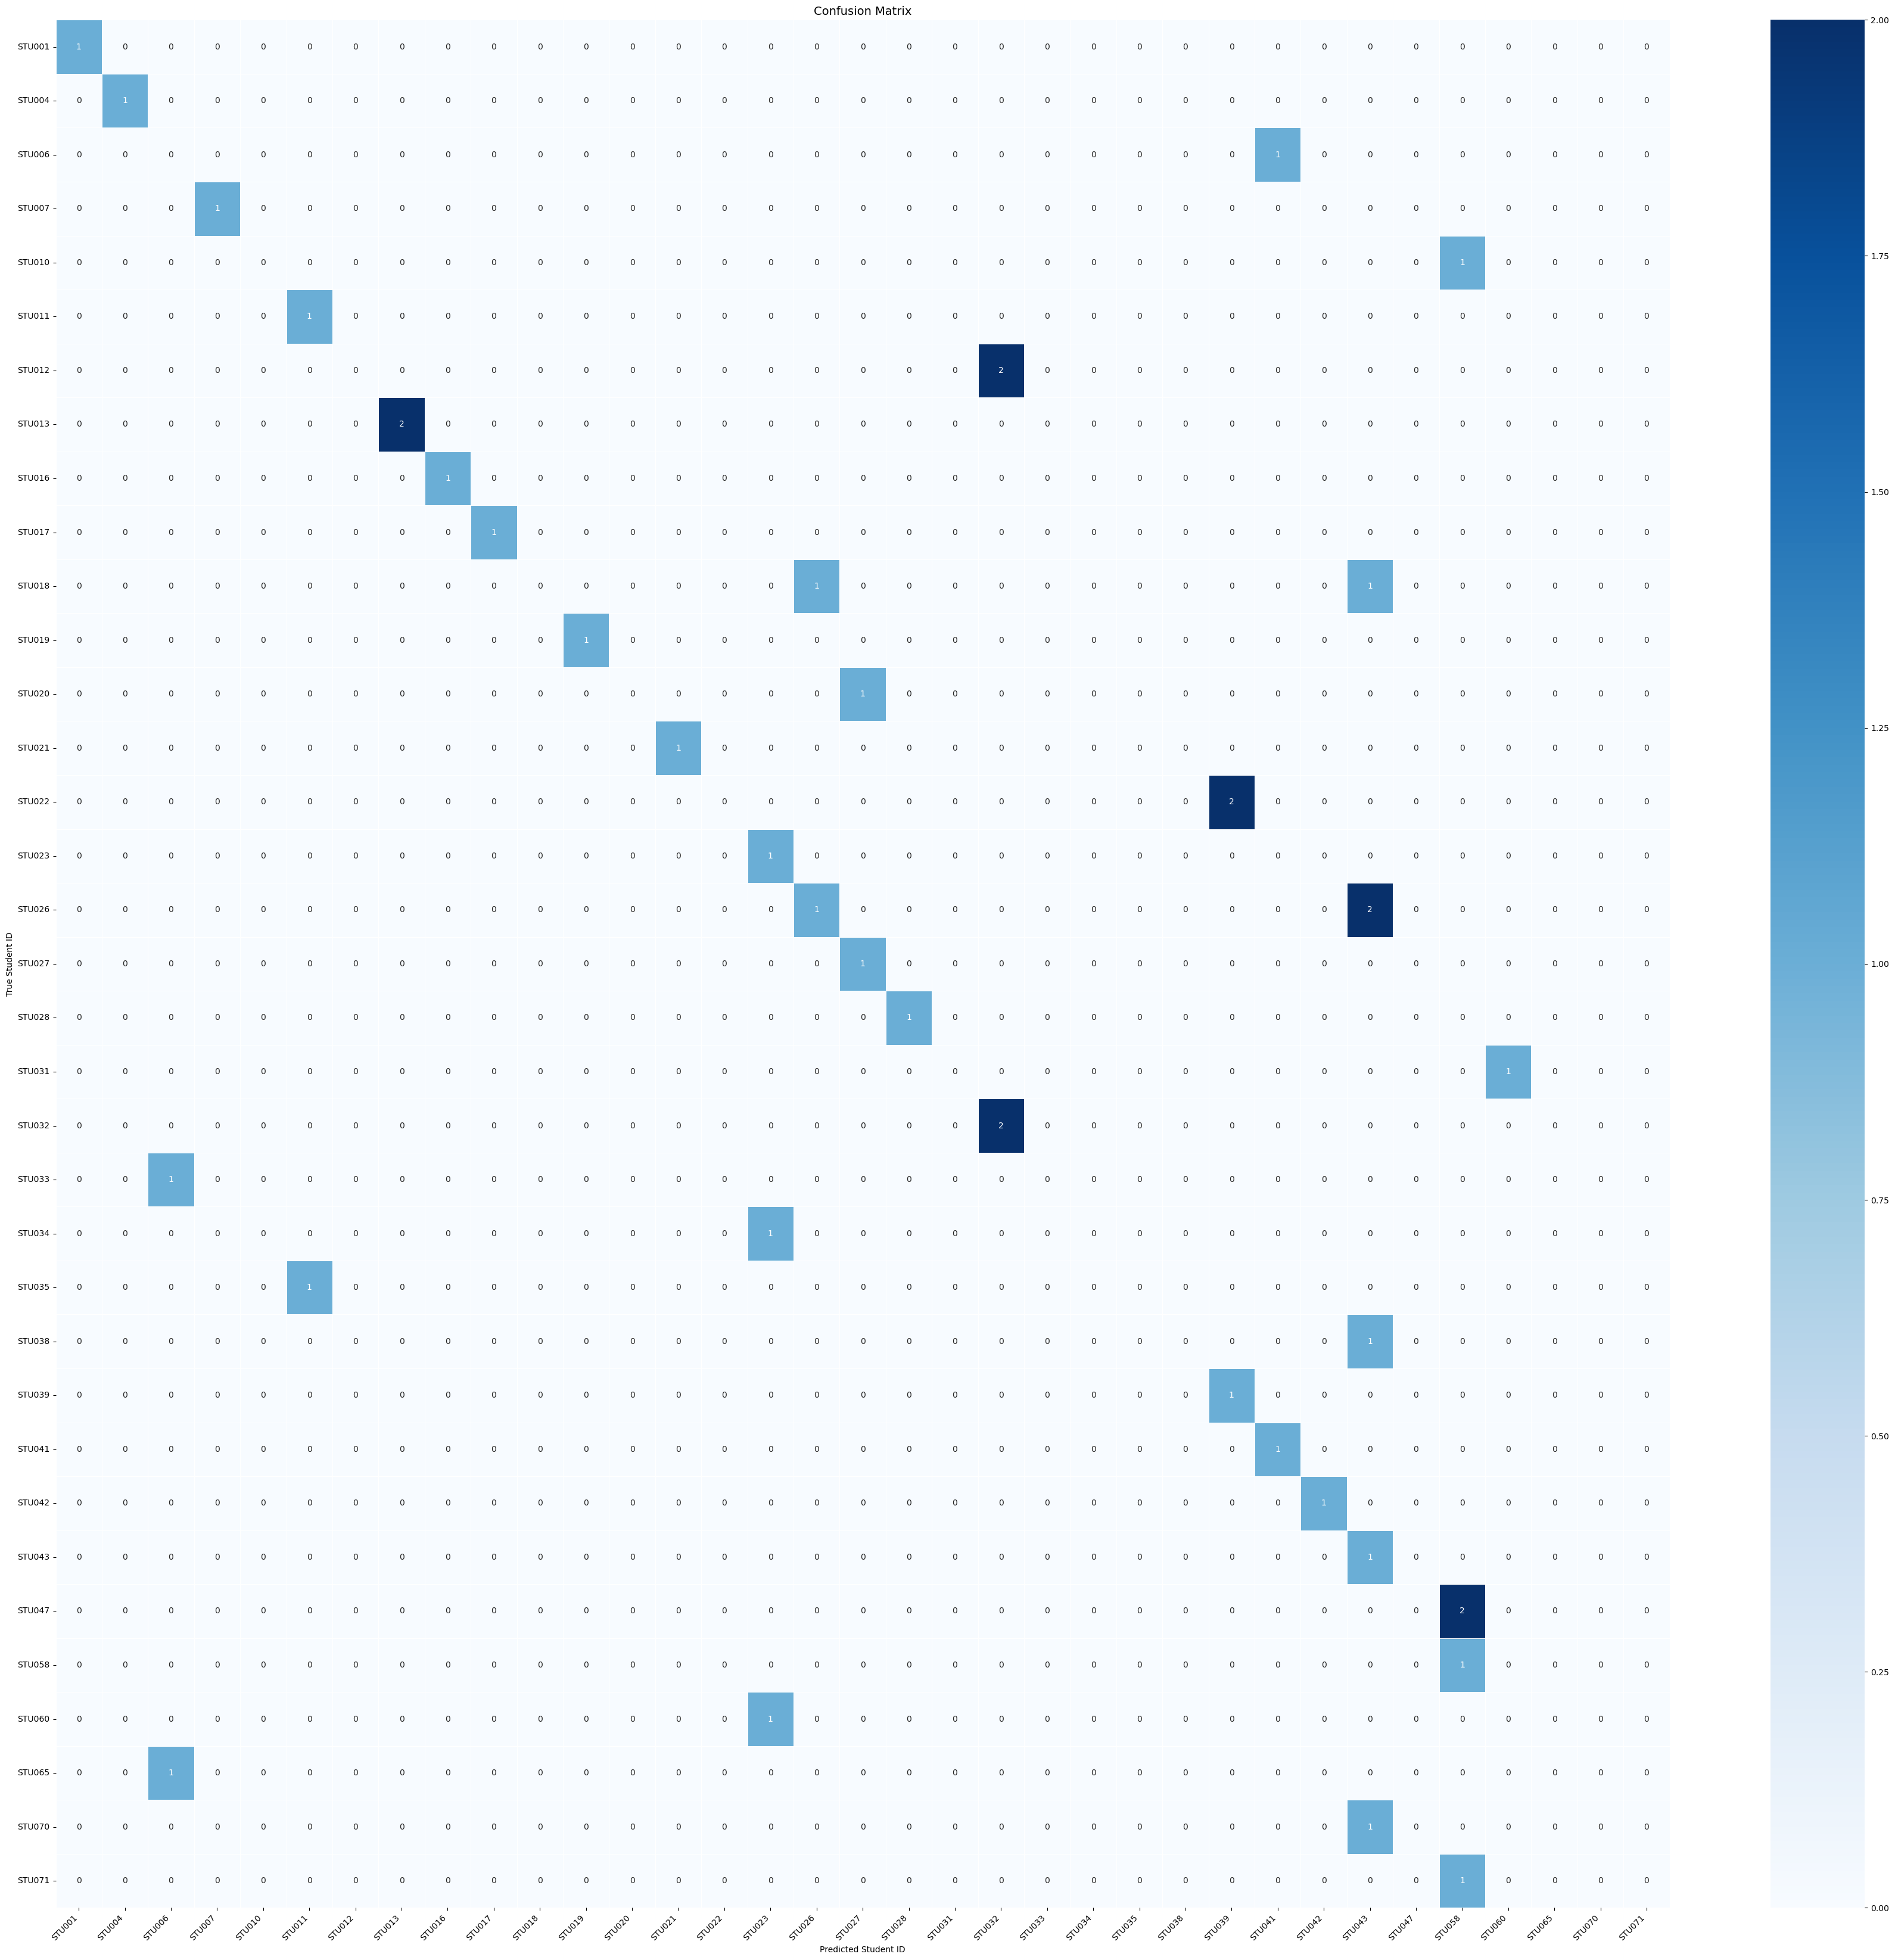

Correctly classified: 21 out of 43


In [25]:
# Cell 25 — Confusion matrix heatmap
cm = confusion_matrix(y_test_encoded, y_pred_encoded)

plt.figure(figsize=(max(8, NUM_CLASSES), max(6, NUM_CLASSES - 2)))
sns.heatmap(
    cm,
    annot       = True,
    fmt         = 'd',
    cmap        = 'Blues',
    xticklabels = le.classes_,
    yticklabels = le.classes_,
    linewidths  = 0.5
)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Student ID')
plt.ylabel('True Student ID')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

correct = np.trace(cm)
total   = cm.sum()
print(f'Correctly classified: {correct} out of {total}')

In [26]:
# Cell 26 — Save model weights and architecture config
torch.save(model.state_dict(), 'face_recognition_model.pth')
print('Model weights saved as face_recognition_model.pth')

model_config = {
    'num_classes': NUM_CLASSES,
    'img_size'   : IMG_SIZE,
}
with open('model_config.pkl', 'wb') as f:
    pickle.dump(model_config, f)
print('Model config saved as model_config.pkl')

Model weights saved as face_recognition_model.pth
Model config saved as model_config.pkl


In [27]:
# Cell 27 — Save the label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('Label encoder saved as label_encoder.pkl')
print('Classes saved:', list(le.classes_))

Label encoder saved as label_encoder.pkl
Classes saved: [np.str_('STU001'), np.str_('STU004'), np.str_('STU006'), np.str_('STU007'), np.str_('STU010'), np.str_('STU011'), np.str_('STU012'), np.str_('STU013'), np.str_('STU016'), np.str_('STU017'), np.str_('STU018'), np.str_('STU019'), np.str_('STU020'), np.str_('STU021'), np.str_('STU022'), np.str_('STU023'), np.str_('STU026'), np.str_('STU027'), np.str_('STU028'), np.str_('STU031'), np.str_('STU032'), np.str_('STU033'), np.str_('STU034'), np.str_('STU035'), np.str_('STU038'), np.str_('STU039'), np.str_('STU041'), np.str_('STU042'), np.str_('STU043'), np.str_('STU047'), np.str_('STU058'), np.str_('STU060'), np.str_('STU065'), np.str_('STU070'), np.str_('STU071')]


In [28]:
# Cell 28 — Load the saved model and label encoder
import pickle, torch, numpy as np, cv2, matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

# Load config
with open('model_config.pkl', 'rb') as f:
    model_config = pickle.load(f)
NUM_CLASSES = model_config['num_classes']
IMG_SIZE    = model_config['img_size']

# Re-create model architecture and load weights
# NOTE: FaceCNN must be defined above (Cell 17) before running this cell
loaded_model = FaceCNN(num_classes=NUM_CLASSES)
loaded_model.load_state_dict(
    torch.load('face_recognition_model.pth', map_location='cpu')
)
loaded_model.eval()
print('Model loaded successfully.')
print('Expected input: (N, 3, 128, 128) — batch of RGB tensors')

# Load label encoder
with open('label_encoder.pkl', 'rb') as f:
    loaded_le = pickle.load(f)
print('Label encoder loaded.')
print('Known student IDs:', list(loaded_le.classes_))

Model loaded successfully.
Expected input: (N, 3, 128, 128) — batch of RGB tensors
Label encoder loaded.
Known student IDs: [np.str_('STU001'), np.str_('STU004'), np.str_('STU006'), np.str_('STU007'), np.str_('STU010'), np.str_('STU011'), np.str_('STU012'), np.str_('STU013'), np.str_('STU016'), np.str_('STU017'), np.str_('STU018'), np.str_('STU019'), np.str_('STU020'), np.str_('STU021'), np.str_('STU022'), np.str_('STU023'), np.str_('STU026'), np.str_('STU027'), np.str_('STU028'), np.str_('STU031'), np.str_('STU032'), np.str_('STU033'), np.str_('STU034'), np.str_('STU035'), np.str_('STU038'), np.str_('STU039'), np.str_('STU041'), np.str_('STU042'), np.str_('STU043'), np.str_('STU047'), np.str_('STU058'), np.str_('STU060'), np.str_('STU065'), np.str_('STU070'), np.str_('STU071')]


In [29]:
# Cell 29 — Prediction function for a single image
def predict_student(image_path, model, label_encoder, img_size=(128, 128)):
    """
    Load a face image from disk, preprocess it,
    and return the predicted student ID with confidence.
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f'ERROR: Cannot read image at {image_path}')
        return None, None

    # Preprocess: resize → BGR→RGB → PIL → tensor
    img_resized = cv2.resize(img, img_size, interpolation=cv2.INTER_AREA)
    img_rgb     = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    img_pil     = Image.fromarray(img_rgb)

    preprocess = transforms.Compose([transforms.ToTensor()])
    img_tensor = preprocess(img_pil).unsqueeze(0)  # (1, C, H, W)

    # Inference
    with torch.no_grad():
        outputs   = model(img_tensor)
        probs     = torch.softmax(outputs, dim=1)[0]
        pred_cls  = probs.argmax().item()
        confidence = probs[pred_cls].item()

    student_id = label_encoder.inverse_transform([pred_cls])[0]
    return student_id, confidence


print('predict_student() function defined.')

predict_student() function defined.


Predicted Student ID : STU001
Confidence           : 71.61%


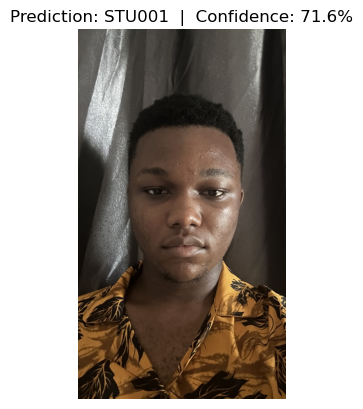

In [30]:
# Cell 30 — Run prediction on a single test image
# Change TEST_IMAGE_PATH to any face image you want to test
TEST_IMAGE_PATH = 'faces/STU001/IMG_0428.jpg'

student_id, confidence = predict_student(TEST_IMAGE_PATH, loaded_model, loaded_le)

if student_id is not None:
    print(f'Predicted Student ID : {student_id}')
    print(f'Confidence           : {confidence * 100:.2f}%')

    img     = cv2.imread(TEST_IMAGE_PATH)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(f'Prediction: {student_id}  |  Confidence: {confidence*100:.1f}%')
    plt.axis('off')
    plt.show()

In [31]:
# Cell 31 — Batch test on the entire test set using the loaded model
from sklearn.metrics import accuracy_score as acc_score

loaded_model.eval()
all_preds_loaded = []
all_true_loaded  = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = loaded_model(images)
        _, preds = torch.max(outputs, 1)
        all_preds_loaded.extend(preds.numpy())
        all_true_loaded.extend(labels.numpy())

loaded_acc = acc_score(all_true_loaded, all_preds_loaded)
print(f'Loaded model test accuracy: {loaded_acc * 100:.2f}%')
print('Save and load successful!' if loaded_acc > 0 else 'Something went wrong.')

Loaded model test accuracy: 48.84%
Save and load successful!


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
